# 03 - Direct Sun Hours: Advanced Surfaces + Multi-Month Window

**What it computes.** The number of hours a point is in **direct** (unshaded)
sunlight over the window - the metric behind right-to-light / overshadowing
checks and amenity-space sunlight rules. Standard = 512x512 ground grid;
**advanced** = direct-sun-hours on building **facades** and **roofs**.

**Advanced inputs gained.** The full surface family (`analysis-surfaces`,
`surface-grid-size`, `partial-cells`, `sensor-points`, `ground-geometry`,
`context-geometry`) **plus** forward **multi-month / annual** `time-period`
windows - aggregated as per-month representative days.

**When to use.** Facade / roof solar-access compliance, overshadowing studies,
seasonal sunlight on amenity terraces.

## Setup

In [1]:
# --- Setup: auth, base URL, geometry (self-contained) -----------------------
# Set your key in the environment first:  export INFRARED_API_KEY=...
# Optionally load a .env file (pip install python-dotenv):
try:
    from dotenv import load_dotenv

    load_dotenv()
except Exception:
    pass

import os

# Default base URL = STAGING (host root, NO /v2) where advanced features deploy
# first. For production set INFRARED_BASE_URL=https://api.infrared.city/v2
os.environ.setdefault("INFRARED_BASE_URL", "https://api-test.infrared.city")

import numpy as np
import ir_advanced as ia
import ir_render as ir

print("base URL :", ia.base_url())
client = ia.make_client()
buildings = ia.fetch_buildings(
    client, ia.VIENNA_KARLSPLATZ, "karlsplatz_buildings.json"
)
print(f"buildings: {len(buildings)} (Vienna Karlsplatz AOI, fetched via SDK + cached)")

base URL : https://api-test.infrared.city
buildings: 132 (Vienna Karlsplatz AOI, fetched via SDK + cached)


In [2]:
# Weather: nearest TMY file to the AOI, filtered to the analysis window.
from infrared_sdk.models import TimePeriod

weather_id = ia.fetch_weather_identifier(client)
print("weather file:", weather_id)

weather file: AUT_WI_Wien-Innere.Stadt.110340_TMYx.2009-2023


## Multi-month window

We use a **summer half-year** window (Apr-Sep) to show the advanced
`time-period`. Direct-sun-hours aggregates this as per-month representative
days, so the result is the typical direct-sun-hours profile across the season.

In [3]:
from infrared_sdk.analyses.types import SolarModelRequest, AnalysesName

# Forward multi-month window (Apr 1 -> Sep 30). Wrapping windows are rejected.
tp = TimePeriod(
    start_month=4, start_day=1, start_hour=4, end_month=9, end_day=30, end_hour=20
)


def dsh_body():
    b = SolarModelRequest(
        analysis_type=AnalysesName.direct_sun_hours,
        latitude=ia.VIENNA_LAT,
        longitude=ia.VIENNA_LON,
        time_period=tp,
    ).to_dict()
    b["latitude"] = ia.VIENNA_LAT
    b["longitude"] = ia.VIENNA_LON
    b["geometries"] = buildings
    return b


grid_res, info = ia.run_job("direct-sun-hours", dsh_body(), label="grid-multimonth")
grid = np.array(grid_res["output"], dtype=float)
print("grid shape:", grid.shape, "| elapsed:", info["elapsed_s"], "s")

[direct-sun-hours/grid-multimonth] Succeeded in 3.2s  keys=['max-legend', 'min-legend', 'output']
grid shape: (512, 512) | elapsed: 3.2 s


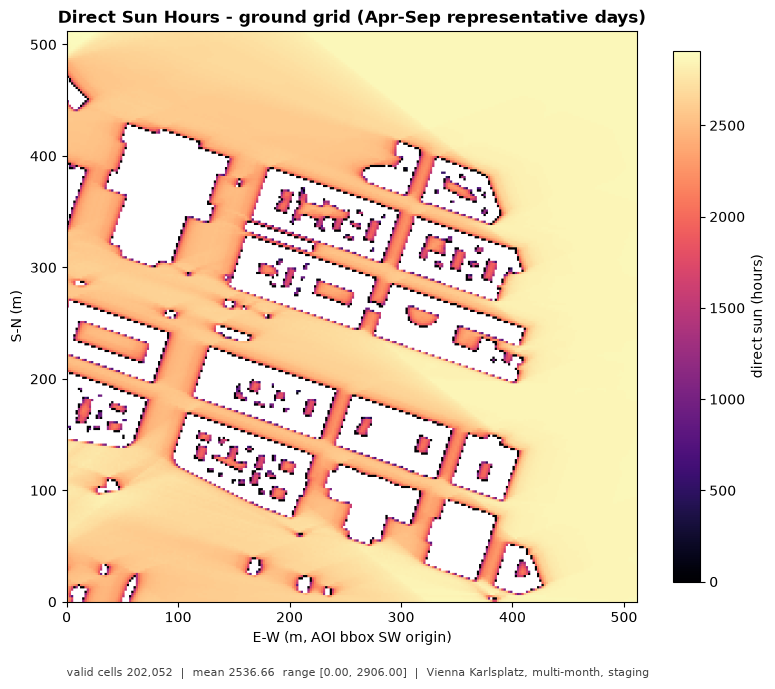

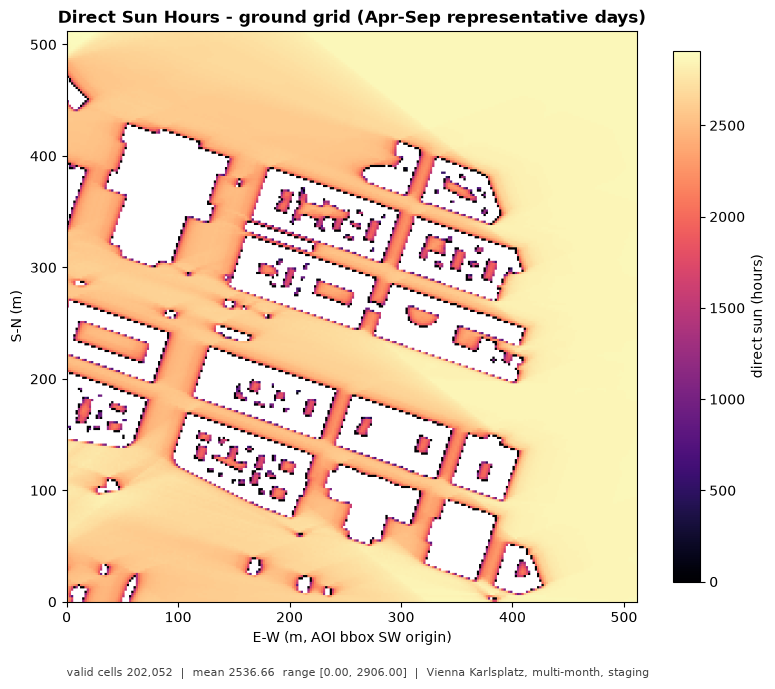

In [4]:
fig, ax = ir.grid_heatmap(
    grid,
    title="Direct Sun Hours - ground grid (Apr-Sep representative days)",
    cbar_label="direct sun (hours)",
    cmap="magma",
    crop=True,
    note="Vienna Karlsplatz, multi-month, staging",
)
fig

## Advanced run - facade direct-sun-hours

`analysis-surfaces:"facades"`. Same `surfaces` payload shape as `01`/`02`.
South / west facades pick up the most direct sun; the colored mesh makes the
orientation dependence obvious.

In [5]:
body = dsh_body()
body["analysis-surfaces"] = "facades"
body["surface-grid-size"] = 4.0
body["surface-offset"] = 0.1
body["partial-cells"] = True
body["min-coverage"] = 0.25
fac_res, info = ia.run_job("direct-sun-hours", body, label="facades")
print("frames:", len(fac_res["surfaces"]), "| sensors:", fac_res["sensor-count"])

[direct-sun-hours/facades] Succeeded in 6.1s  keys=['aggregates', 'max-legend', 'min-legend', 'sensor-count', 'surfaces']  sensors=44276
frames: 2724 | sensors: 44276


### Result payload, described

Same surface schema as solar radiation / daylight (notebook `01`): per-frame
`{origin, u-axis, v-axis, grid-size, nu, nv, values, area, mean, peak}`,
per-building `aggregates`, and `sensor-count`. `values` here are **direct sun
hours** (representative-day average across the multi-month window).

In [6]:
import json

fk = next(iter(fac_res["surfaces"]))
print(
    "frame",
    fk,
    "->",
    json.dumps(
        {
            k: fac_res["surfaces"][fk][k]
            for k in ("grid-size", "nu", "nv", "area", "mean", "peak")
        },
        default=float,
    ),
)
print(
    "AOI-wide sensor-count:",
    fac_res["sensor-count"],
    "| legend:",
    fac_res["min-legend"],
    "->",
    fac_res["max-legend"],
)

frame 11155/0 -> {"grid-size": 4.0, "nu": 1, "nv": 8, "area": 128.0, "mean": 814.875, "peak": 1195.0}
AOI-wide sensor-count: 44276 | legend: 0 -> 3111


## Render - colored direct-sun-hours mesh

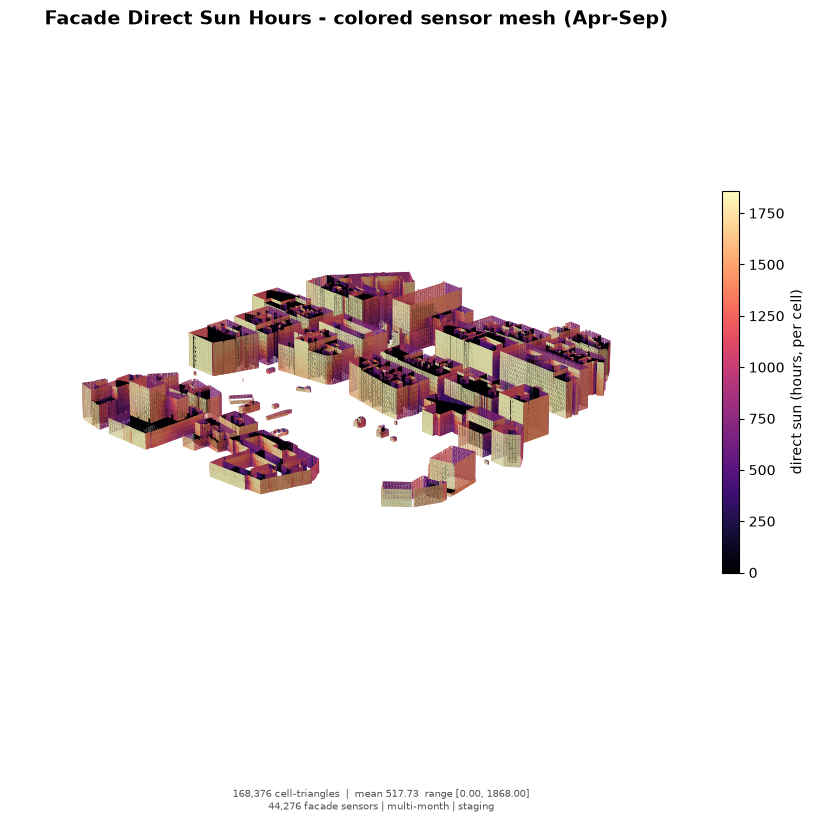

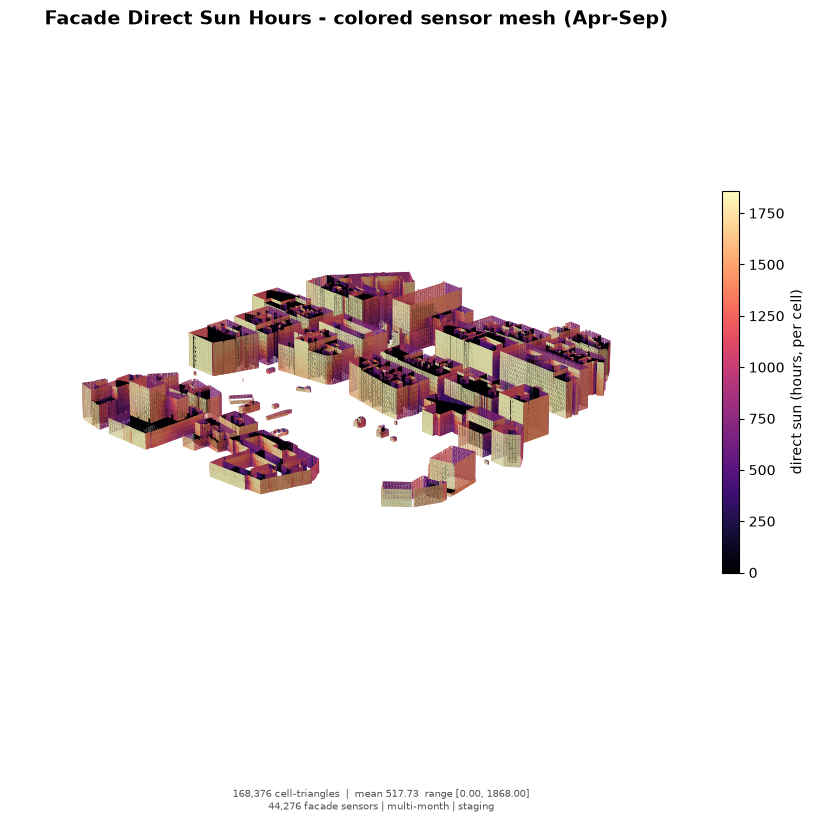

In [7]:
tris, values, normals = ia.reconstruct_cells(fac_res["surfaces"])
fig, ax = ir.surface_mesh(
    tris,
    values,
    normals=normals,
    context_faces=ia.building_faces(buildings),
    title="Facade Direct Sun Hours - colored sensor mesh (Apr-Sep)",
    cbar_label="direct sun (hours, per cell)",
    cmap="magma",
    zmax=45,
    note=f"{fac_res['sensor-count']:,} facade sensors | multi-month | staging",
)
fig

## Summary

* Forward multi-month / annual windows are accepted (wrapping windows -> 400).
* DSH aggregates the window as per-month representative days.
* The surface mode + payload shape is identical to solar radiation / daylight.